In [25]:
from astropy.io import fits
from astropy.timeseries import LombScargle

import numpy as np
import matplotlib.pyplot as plt

from scipy.io import readsav
from sklearn.decomposition import PCA

from tqdm import tqdm

import tools as t

In [26]:
# load files
path_data = '../data/'
data_spectra = fits.getdata(path_data + 'flux_norm_paq12_6173_lionel_tau1_scalingspatial1_sansrotation.fits')
data_rv = readsav(path_data + 'res_rv_bis_6173_lionel_tau1_scaling1_sansrot.sav')
data_rv.keys()

dict_keys(['rv_gauss', 'rv_correl', 'rv_deriv', 'xbiss', 'ybiss', 'l_true', 'lambd', 'flux_moy'])

data_spectra: matrix with 3686 spectra of 122 elements each \
data_rv: dictionary

In [58]:
c = 3e8
# extract data
wl = data_rv['lambd']
rv = data_rv['rv_correl']
template = data_rv['flux_moy']
times = np.arange(0, len(data_spectra) * 144, 144) / 60 / 24  # time in days
times

array([0.000e+00, 1.000e-01, 2.000e-01, ..., 3.683e+02, 3.684e+02,
       3.685e+02], shape=(3686,))

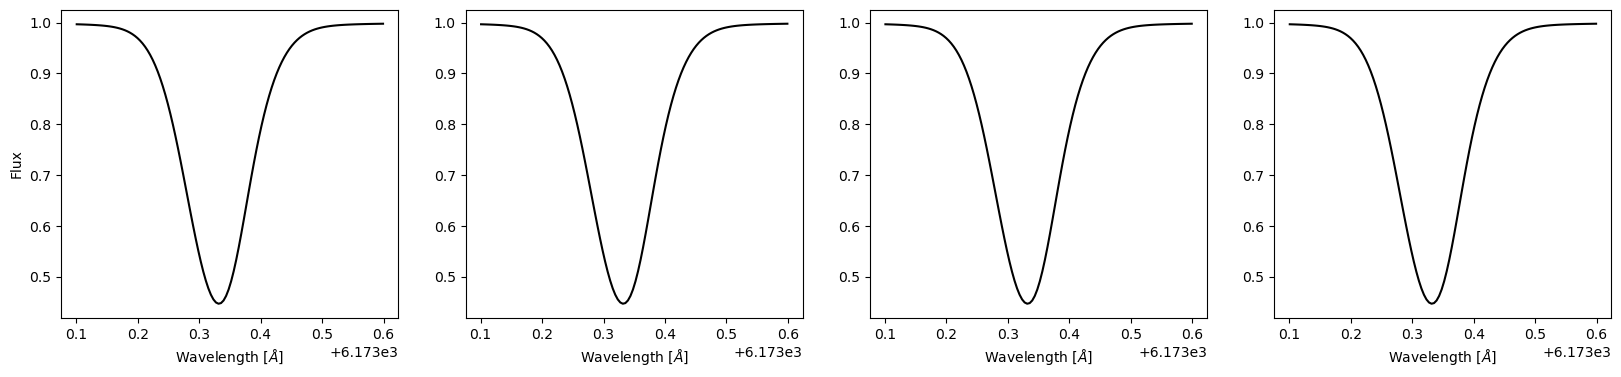

In [59]:
# plot some spectra

n_spectra = 4
fig, axs = plt.subplots(1, n_spectra, figsize=(20, 4))
axs[0].set_ylabel('Flux')
for i in range(n_spectra):
    axs[i].plot(wl, data_spectra[i], color='k')
    axs[i].set_xlabel(r'Wavelength [$\AA$]')
plt.show()


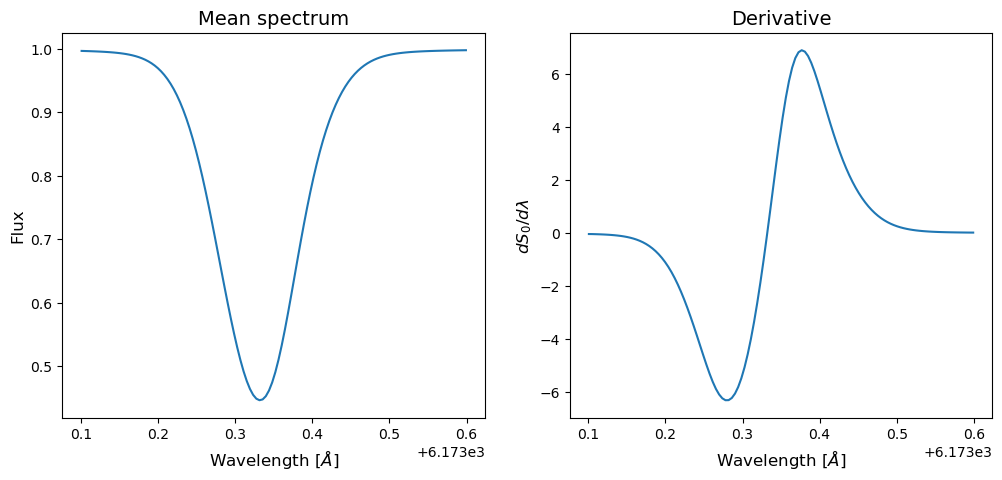

In [60]:
# template matching: calculate the mean spectrum
mean_spec = np.mean(data_spectra, axis=0)
d_S0 = np.gradient(mean_spec, wl)  # derivative of the mean spectrum

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].plot(wl, mean_spec)
axs[0].set_title('Mean spectrum', size=14)
axs[0].set_xlabel(r'Wavelength [$\AA$]', size=12)
axs[0].set_ylabel('Flux', size=12)

axs[1].plot(wl, d_S0)
axs[1].set_title('Derivative', size=14)
axs[1].set_xlabel(r'Wavelength [$\AA$]', size=12)
axs[1].set_ylabel(r'$dS_0 / d\lambda$', size=12)

plt.show()


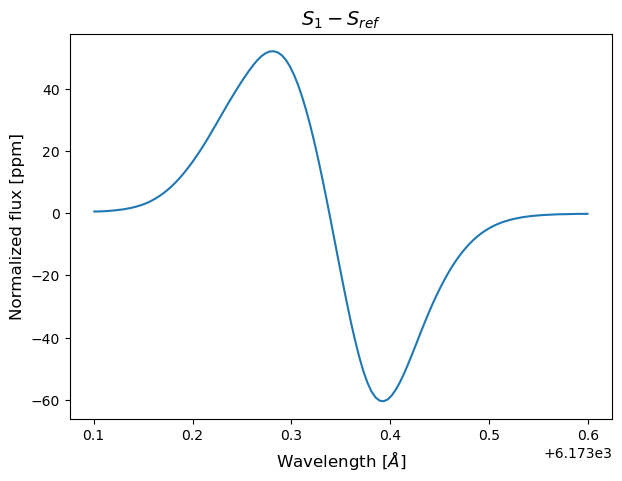

In [61]:
# first spectrum - reference spectrum
# small differences between one spectrum and other
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(wl, (data_spectra[1] - mean_spec) * 10**6)
ax.set_title(r'$S_1 - S_{ref}$', size=14)
ax.set_xlabel(r'Wavelength [$\AA$]', size=12)
ax.set_ylabel('Normalized flux [ppm]', size=12)
plt.show()

In [62]:
# calculate radial velocity
C_0 = 1000
vel = []
for k in range(len(data_spectra)):  # for each spectrum
    vel.append(t.calculate_rv(wl, mean_spec, data_spectra[k], C_0))
vel = np.array(vel)

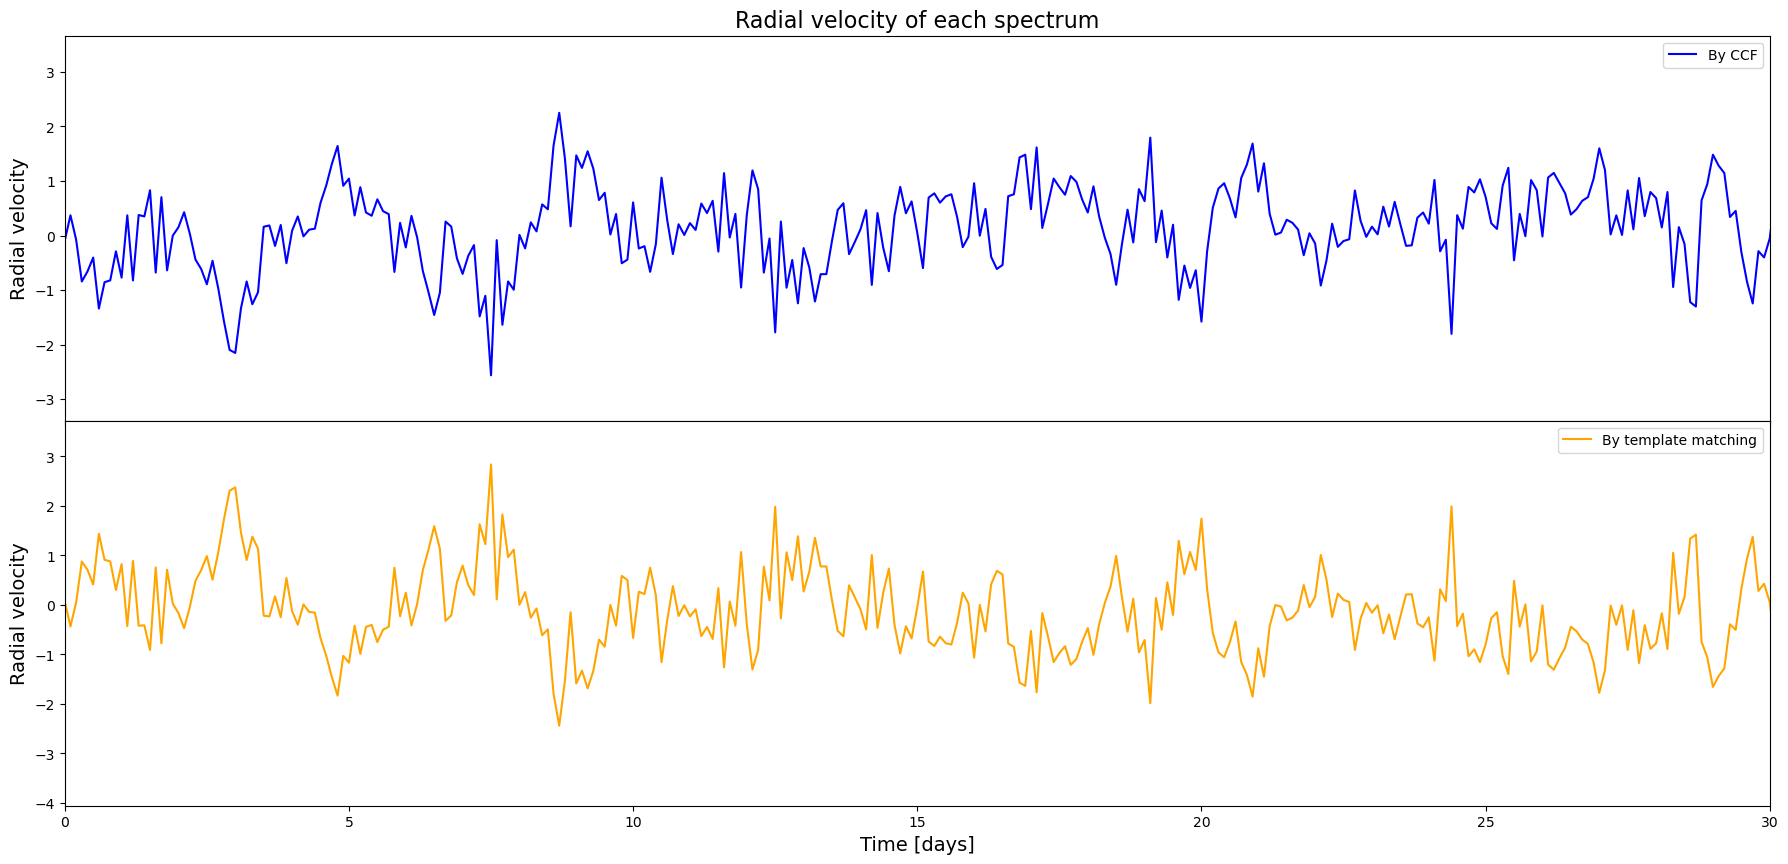

In [68]:
# plot RV
fig, axs = plt.subplots(2, 1, figsize=(22, 10), sharex=True)

axs[0].plot(times, rv, color='blue', label='By CCF')
axs[0].set_title('Radial velocity of each spectrum', size=16)
axs[0].set_ylabel('Radial velocity', size=14)
axs[0].legend()

axs[1].plot(times, vel, color='orange', label='By template matching')
axs[1].set_xlabel('Time [days]', size=14)
axs[1].set_ylabel('Radial velocity', size=14)
axs[1].set_xlim(0, 30)
axs[1].legend()

plt.subplots_adjust(hspace=0)
plt.show()

In [69]:
# get multiplicative factor
factor = vel / rv
print(np.mean(factor), np.median(factor))

-1.160555708708268 -1.1040211343759334


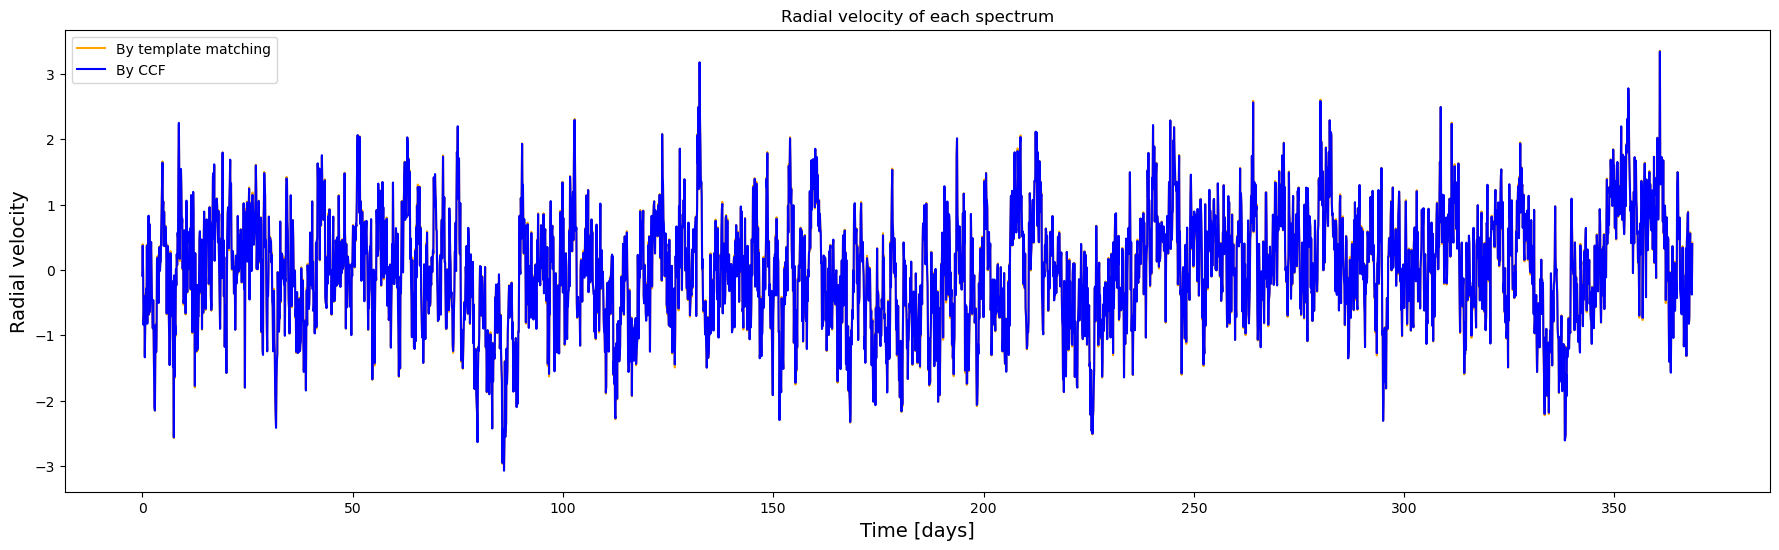

In [70]:
# correct calculated RV by the multiplicative factor, compare
fig, ax = plt.subplots(figsize=(22, 6))

ax.plot(times, vel / np.median(factor), color='orange', label='By template matching')
ax.plot(times, rv, color='blue', label='By CCF')
ax.set_title('Radial velocity of each spectrum')
ax.set_xlabel('Time [days]', size=14)
ax.set_ylabel('Radial velocity', size=14)
#ax.set_xlim(0, 500)
ax.legend()

plt.show()

/tmp/ipykernel_1419750/1193137506.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


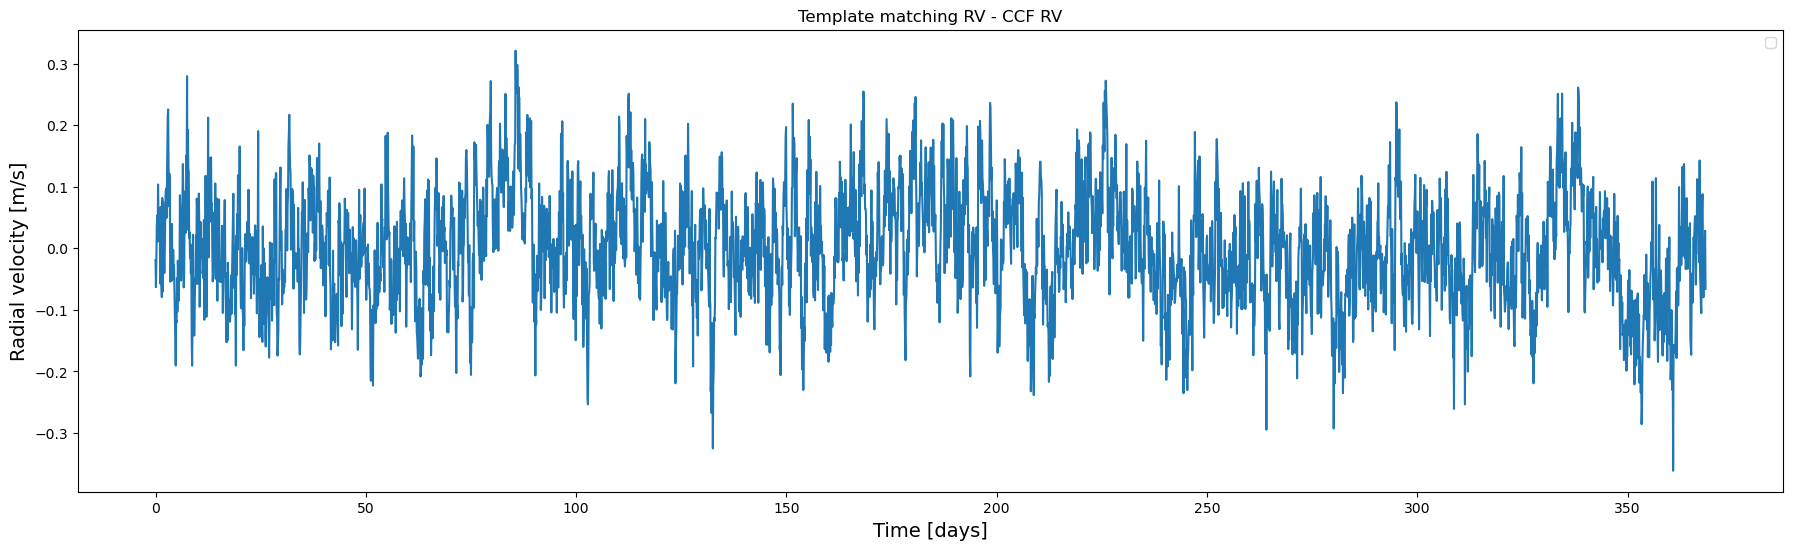

In [71]:
fig, ax = plt.subplots(figsize=(22, 6))

ax.plot(times, vel + rv)
ax.set_title('Template matching RV - CCF RV')
ax.set_xlabel('Time [days]', size=14)
ax.set_ylabel('Radial velocity [m/s]', size=14)
#ax.set_xlim(0, 500)
ax.legend()

plt.show()

In [72]:
np.std(vel), np.std(rv)

(np.float64(0.9464492535332212), np.float64(0.8569066987128067))

In [73]:
# corrected wavelength
lambda_corr = t.calculate_lambda_corr(wl, rv)

In [74]:
lambda_corr

array([[6173.10077184, 6173.10489084, 6173.10900884, ..., 6173.59086384,
        6173.59498184, 6173.59909984],
       [6173.10076235, 6173.10488135, 6173.10899935, ..., 6173.59085435,
        6173.59497235, 6173.59909035],
       [6173.10077156, 6173.10489056, 6173.10900856, ..., 6173.59086356,
        6173.59498156, 6173.59909956],
       ...,
       [6173.10077063, 6173.10488963, 6173.10900763, ..., 6173.59086263,
        6173.59498063, 6173.59909863],
       [6173.10077774, 6173.10489674, 6173.10901474, ..., 6173.59086974,
        6173.59498774, 6173.59910574],
       [6173.10076185, 6173.10488085, 6173.10899885, ..., 6173.59085385,
        6173.59497185, 6173.59908985]], shape=(3686, 122))

In [75]:
# interpolation to a common reference grid, as lambda_corr is different for each spectrum

resampled_flux = []

for wave, flux in zip(lambda_corr, data_spectra):  # iterate over wavelength, spectrum pairs
    interp_flux = np.interp(wl, wave, flux)  # interpolate the observed spectrum into the reference grid
    resampled_flux.append(interp_flux)  # save

spectra_matrix = np.array(resampled_flux)

In [76]:
# apply double centering to the spectra matrix
spectra_centered = t.double_centering(spectra_matrix)

In [77]:
# apply PCA to the centered spectra matrix
n_components = 20
pca_flux = PCA(n_components=n_components)  # create PCA object
pcs  = pca_flux.fit_transform(spectra_centered)  # fit the model with spectra_centered and apply the dimensionality reduction
var  = pca_flux.explained_variance_ratio_
print(f'Variance explained by the {n_components} components:', var)  # how much information (variance) can be attributed to each of the principal components

Variance explained by the 20 components: [5.84058761e-01 3.37753042e-01 7.44346744e-02 2.20807852e-03
 1.32671794e-03 1.44220570e-04 4.44046650e-05 1.26668343e-05
 8.10830686e-06 4.93663843e-06 1.60434188e-06 1.25245686e-06
 3.95939414e-07 1.24909119e-07 9.19352324e-08 7.64845279e-08
 1.59823771e-08 1.23543483e-08 1.14953082e-08 1.12403799e-08]


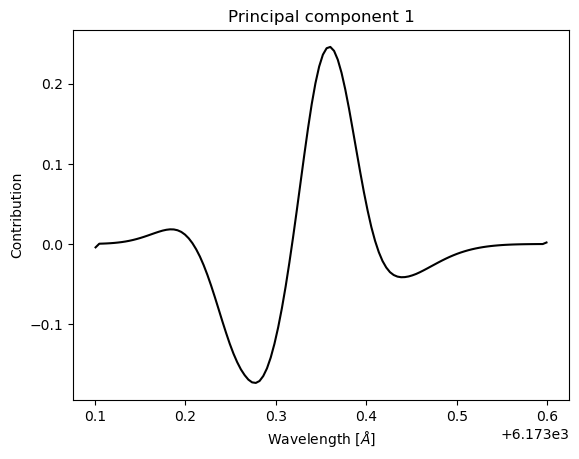

In [78]:
# plot loadings
# plot shows how much each wavelength value (feature) contributes to the variance of a PC
for i in range(1):  # put n_components instead of 1 to see all the plots
    plt.plot(wl, pca_flux.components_[i], color='k')
    plt.title(f'Principal component {i + 1}', size=12)
    plt.xlabel(r'Wavelength [$\AA$]')
    plt.ylabel('Contribution')
    plt.show()

In [79]:
# component significance
# multiple realizations allow to calculate error bars

n_realizations = 20

# reduce the size of the data to reduce memory usage
spectra_centered = spectra_centered.astype(np.float32)
comps = pca_flux.components_.astype(np.float32)

simi_all = np.empty((n_realizations, n_components, n_components), dtype=np.float32)  # n_realizations squared matrices of n_components x n_components

for i in tqdm(range(n_realizations)):  # iterate over realizations
    spectra_noisy = spectra_centered + np.random.normal(0, .0000005, spectra_centered.shape)  # add gaussian noise to the original data

    pca_noisy = PCA(n_components=n_components, svd_solver="randomized")  # apply PCA to the noisy matrix
    pca_noisy.fit(spectra_noisy)

    comps_noisy = pca_noisy.components_  # save the loadings

    simi_all[i] = comps @ comps_noisy.T  # save dot product between original and noisy loadings

100%|██████████| 20/20 [00:00<00:00, 28.42it/s]


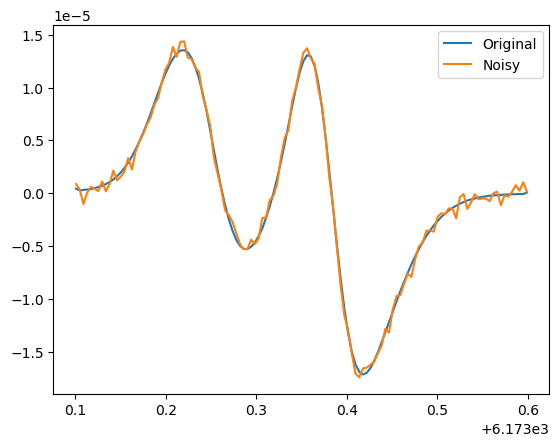

In [80]:
spectra_noisy = spectra_centered + np.random.normal(0, .0000005, len(wl))  # add gaussian noise to the original data
plt.plot(wl, spectra_centered[0], label='Original')
plt.plot(wl, spectra_noisy[0], label='Noisy')
plt.legend()
plt.show()

In [81]:
maxes = np.array([np.amax(s, axis=1) for s in simi_all])  # max of each row of each realization
mean_maxes = np.array([(np.average(s), np.std(s)) for s in maxes.T])  # list of max mean and std for each PC: [(max_avg_1, max_std_1), (max_avg_2, max_std_2), ..., (max_avg_n, max_std_n)]

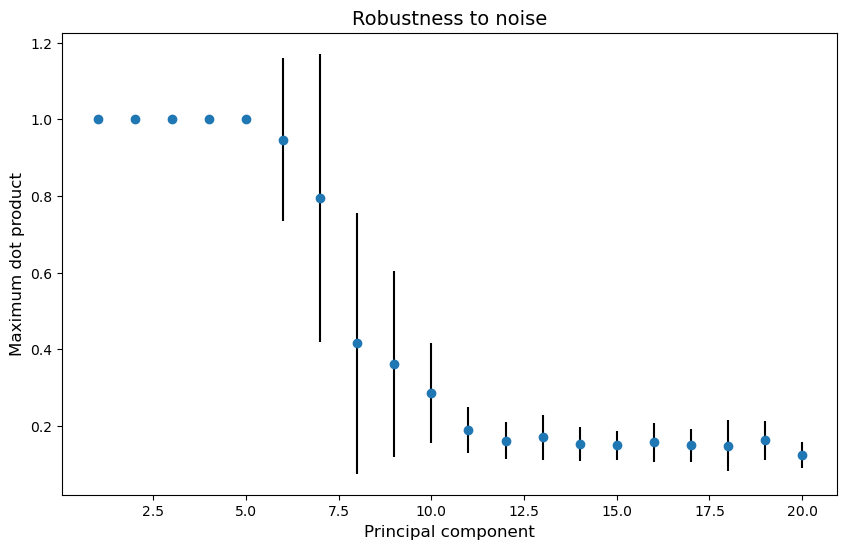

In [82]:
# plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(np.linspace(1, n_components, n_components), mean_maxes[:, 0], mean_maxes[:, 1], fmt='o', ecolor='k')
ax.set_title('Robustness to noise', size=14)
ax.set_xlabel('Principal component', size=12)
ax.set_ylabel('Maximum dot product', size=12)
plt.show()

In [85]:
dt = times[1] - times[0]
sp = np.array([np.fft.fft(pcs[:, i]) for i in range(n_components)])
freq = np.array([np.fft.fftfreq(pcs[:, i].shape[0], dt) for i in range(n_components)]) / 10  # frequency in cycles per unit of the sample spacing: 1 / 144 min -> divide by 10 to get 1 / day
power = np.abs(sp)**2

#periodograms = [LombScargle(times, pcs[:, i]).autopower() for i in range(n_components)]

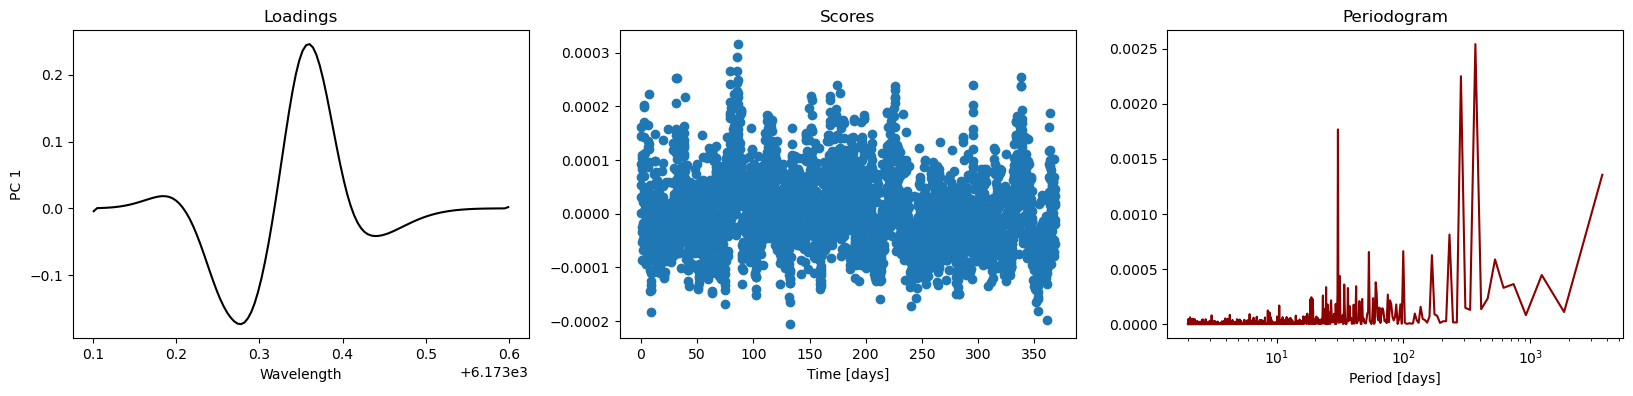

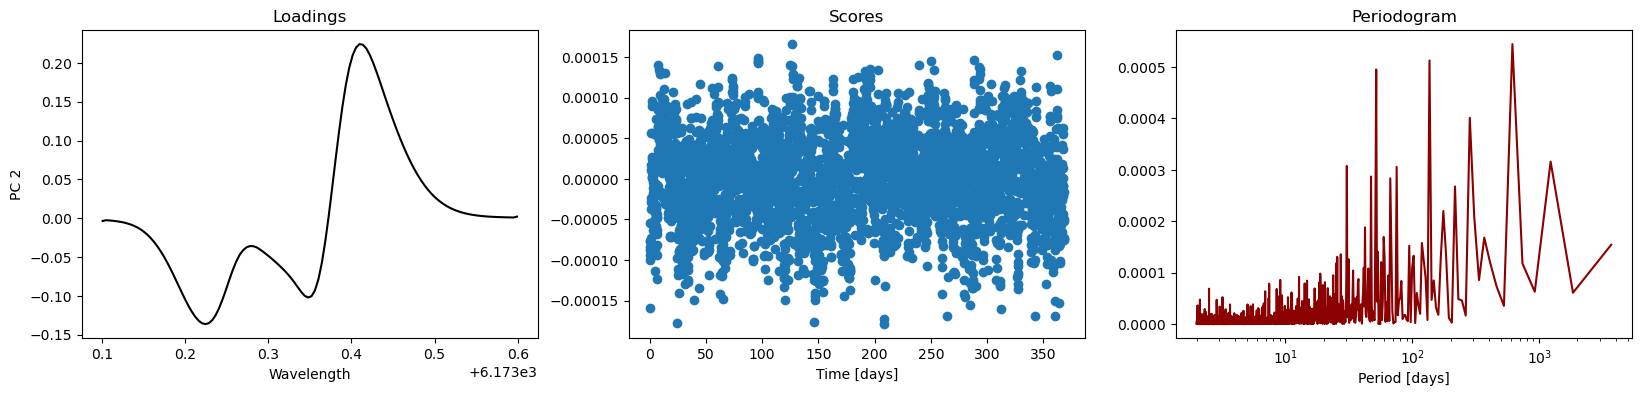

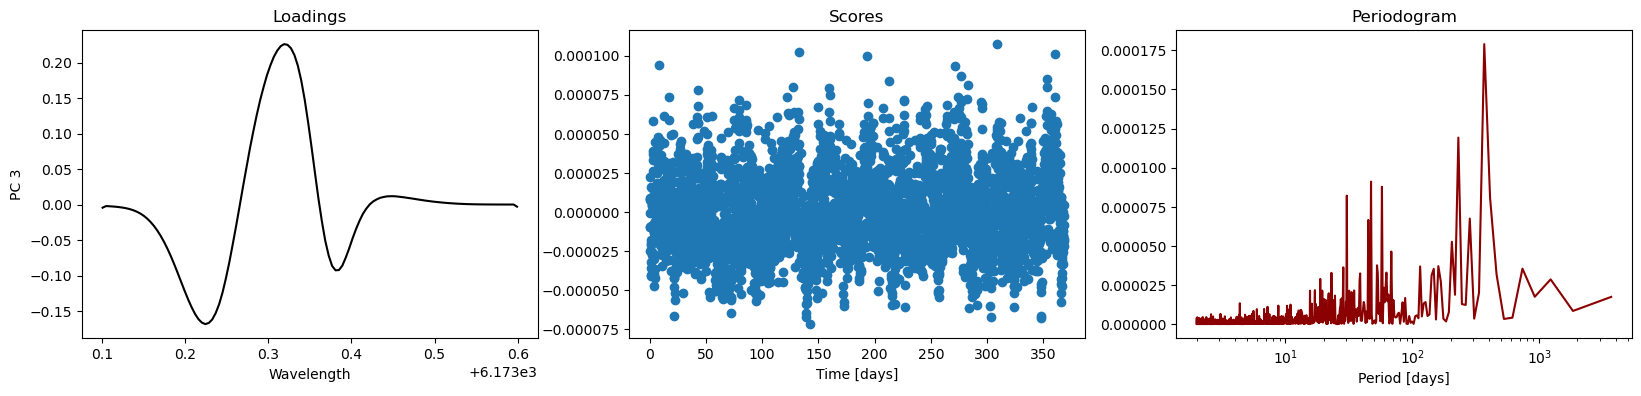

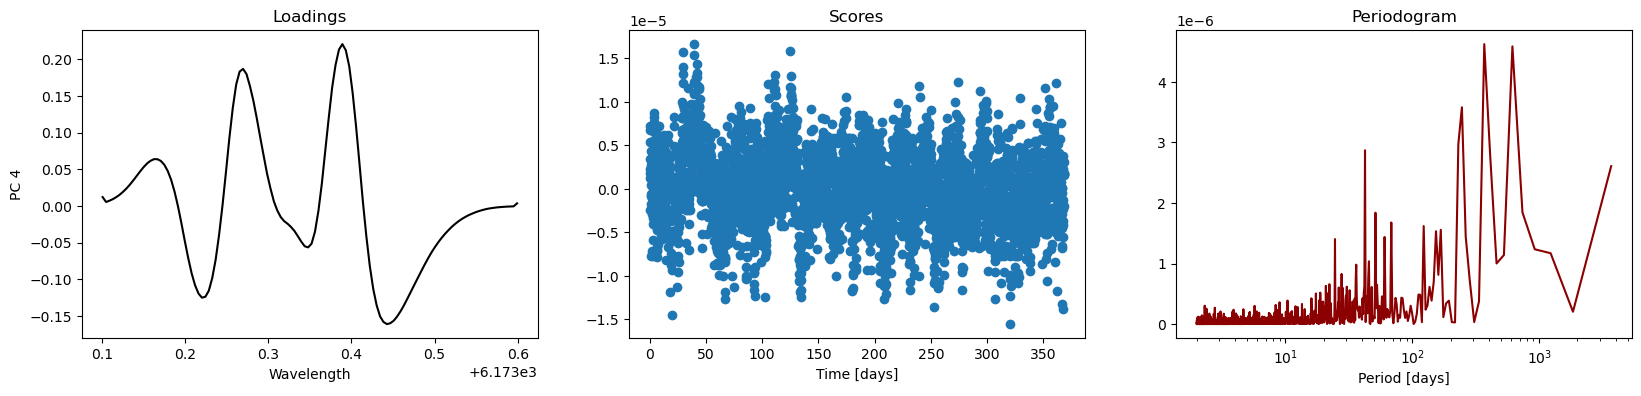

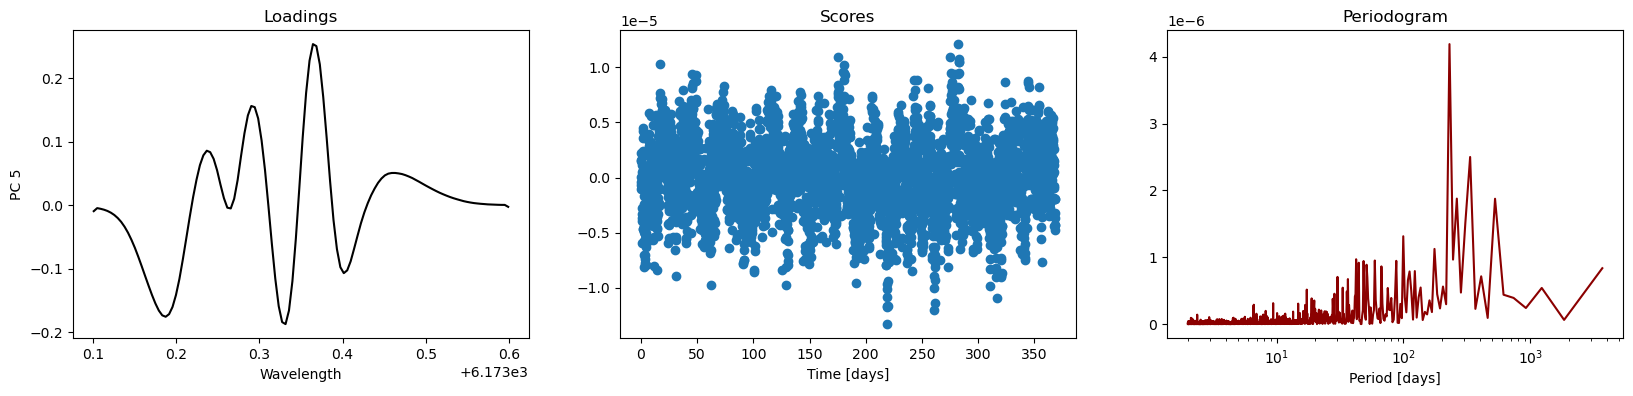

In [86]:
# plot
for i in range(5):
    fig, axs = plt.subplots(1, 3, figsize=(20, 4))
    
    # Loadings
    axs[0].plot(wl, pca_flux.components_[i], color='k')
    axs[0].set_title('Loadings', size=12)
    axs[0].set_xlabel('Wavelength')
    axs[0].set_ylabel(f'PC {i + 1}')
    
    # Scores
    axs[1].scatter(times, pcs[:, i])
    axs[1].set_title('Scores', size=12)
    axs[1].set_xlabel('Time [days]')

    # Fourier periodogram
    #axs[2].plot(1 / periodograms[i][0], periodograms[i][1], color='darkred')
    mask = freq[i] > 0
    axs[2].plot(1 / freq[i][mask], power[i][mask], color='darkred')
    axs[2].set_xscale('log')
    axs[2].set_title('Periodogram', size=12)
    axs[2].set_xlabel('Period [days]')
    
    plt.show()